In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [92]:
df_avg = pd.read_csv("../../../data/processed/3_year/Defenders/Avg_Top5_Defenders.csv")

In [93]:
df_avg.head()

,player id,player,team,team id,league,position,number_of_seasons,minutesplayed,rating,accuratecrossespercentage,...,shots_on_target_pct,inside_box_shot_pct,assist_conversion,xa_per_keypass,final_third_pass_pct,dribbles_per_touch,dispossessed_per_touch,possession_lost_per_touch,defensive_actions_per90,weak_foot_goals_pct
0,3041,Raúl Albiol,Pisa,2737,Italy Serie A,Defenders,3,1245.333333,6.752041,100.000000,...,0.111111,1.000000,0.333333,0.173333,0.061365,0.000000,0.001801,0.114914,5.010707,0.00
1,3577,Dante,Nice,1661,France Ligue 1,Defenders,3,1887.333333,6.981739,8.333333,...,0.258065,0.838710,0.105263,0.105263,0.088193,0.002045,0.001859,0.099071,8.774285,0.00
2,14718,Lorenzo De Silvestri,Bologna,2685,Italy Serie A,Defenders,3,754.000000,6.768000,25.641026,...,0.461538,0.769231,0.000000,0.060000,0.156062,0.001362,0.002725,0.161444,4.297082,0.00
3,19352,Matteo Darmian,Inter,2697,Italy Serie A,Defenders,3,1484.000000,6.794412,30.508475,...,0.476190,0.714286,0.078947,0.071316,0.198627,0.003028,0.002355,0.151413,4.487871,0.25
4,21555,César Azpilicueta,Sevilla,2833,Spain La Liga,Defenders,3,1172.000000,6.893929,28.571429,...,0.500000,0.500000,0.142857,0.141429,0.176686,0.001367,0.003075,0.142808,6.655290,0.00


In [94]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['rating','minutesplayed','number_of_seasons'])

In [95]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [96]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

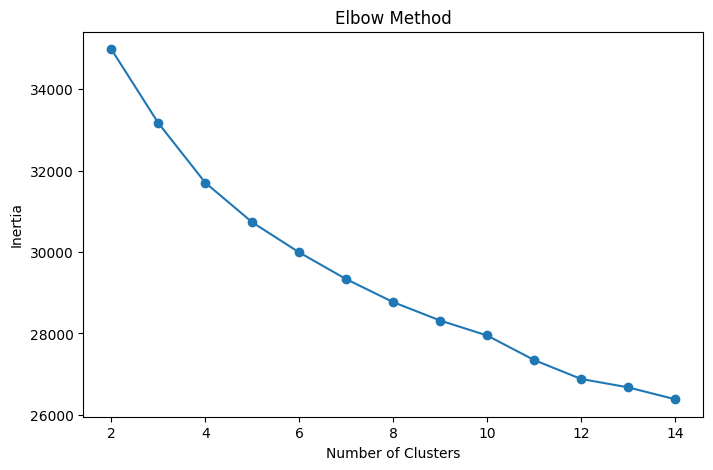

In [97]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [98]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

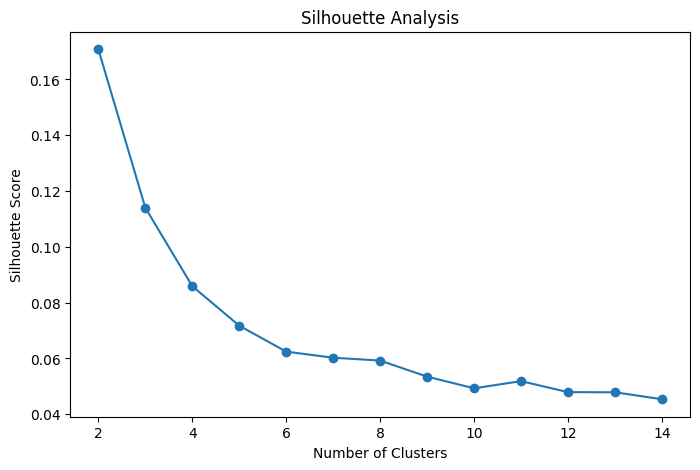

In [99]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [100]:
x=4
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [101]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_4,0,1,2,3
number_of_seasons,2.589552,2.389892,2.557895,2.638298
minutesplayed,1865.776119,1699.948857,1654.521930,1574.572695
rating,6.973234,6.817432,6.763108,6.865074
accuratecrossespercentage,18.567625,21.261512,23.222310,23.007956
accuratelongballspercentage,45.892953,46.362387,40.729320,43.958330
successfuldribblespercentage,61.438471,61.098754,48.419372,48.092664
tackleswonpercentage,61.856008,60.855850,61.692219,62.892617
penaltyconversion,5.970149,0.000000,1.842105,3.723404
setpiececonversion,0.270078,0.030084,0.210526,3.264784
aerialduelswonpercentage,61.364077,57.684473,49.624170,46.880750


In [102]:
df_avg[f'cluster_{x}'].value_counts()

cluster_4
1    277
2    190
0    134
3     94
Name: count, dtype: int64

In [103]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','goals_per90','expectedgoals_per90'], 
    title=f"Forwards Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

In [104]:
for cluster_num in sorted(df_avg['cluster_4'].unique()):
    print(f"\n=======================================================")
    print(f"CLUSTER NUMBER- {cluster_num} (Total Players: {df_avg[df_avg['cluster_4'] == cluster_num].shape[0]})")
    print(f"=======================================================")
    
    slice_df = df_avg[df_avg['cluster_4'] == cluster_num]
    print(slice_df[['player', 'team', 'league']].head(20).to_string(index=False))


CLUSTER NUMBER- 0 (Total Players: 134)
            player              team                 league
Christian Kabasele           Udinese          Italy Serie A
     Marcos Alonso        Celta Vigo          Spain La Liga
   Leandro Cabrera          Espanyol          Spain La Liga
   Florian Lejeune    Rayo Vallecano          Spain La Liga
    Stefan de Vrij             Inter          Italy Serie A
        Ben Davies Tottenham Hotspur England Premier League
          Dan Burn  Newcastle United England Premier League
       Marc Bartra        Real Betis          Spain La Liga
      Fabian Schär  Newcastle United England Premier League
       Stefan Bell   1. FSV Mainz 05     Germany Bundesliga
     Michael Keane           Everton England Premier League
       Willi Orbán        RB Leipzig     Germany Bundesliga
          Emre Can Borussia Dortmund     Germany Bundesliga
   Matthias Ginter       SC Freiburg     Germany Bundesliga
      Lukas Kübler       SC Freiburg     Germany Bundesliga


In [105]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [106]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [107]:
pca_sizes = [16,17,18,19,20]

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [108]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 14):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [109]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,16,4,0.124282
10,17,4,0.123032
20,18,4,0.116599
30,19,4,0.114759
1,16,5,0.111827
40,20,4,0.111514
11,17,5,0.106765
12,17,6,0.106743
21,18,5,0.105684
31,19,5,0.103547


In [110]:
x=16
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
accuratecrossespercentage,0.029037,-0.046339,-0.043857,0.011051,0.119041,-0.003969,-0.003822,-0.022356,-0.040253,-0.136787,-0.245406,0.047746,0.130080,0.268073,-0.092475,0.431262
accuratelongballspercentage,-0.061550,0.061002,-0.185072,0.247923,-0.113422,0.163150,-0.090682,0.270623,0.057672,0.094888,0.009985,-0.198912,0.017286,0.000475,-0.063765,0.105377
successfuldribblespercentage,-0.096895,0.024585,-0.003248,0.168237,-0.032446,0.072626,-0.008985,-0.111953,0.059762,0.015984,0.318914,-0.165076,0.145012,-0.105750,-0.193789,0.306833
tackleswonpercentage,0.036198,0.038896,0.003135,0.050122,-0.048037,0.016055,-0.109010,0.131541,-0.028420,0.197151,0.106164,0.485216,-0.147307,0.248999,0.307360,0.037884
penaltyconversion,0.034399,0.083356,-0.035614,0.230838,0.025717,-0.205044,0.035199,-0.101652,0.486481,-0.174489,-0.056250,0.079408,-0.087512,-0.090580,-0.069584,-0.087004
setpiececonversion,0.057192,0.034279,-0.042903,0.018349,0.078164,-0.165015,0.051660,-0.061286,0.012937,0.196690,-0.014482,0.370100,-0.079498,-0.217253,-0.172990,0.354276
aerialduelswonpercentage,-0.149401,0.124802,0.088629,0.165627,0.082485,0.008452,0.049386,-0.076776,-0.149152,0.025841,-0.214048,0.018272,-0.217564,-0.219011,0.018413,-0.077660
groundduelswonpercentage,0.126670,-0.098816,0.040866,0.315835,-0.218609,0.104636,0.150166,-0.237378,-0.083992,-0.017015,-0.042582,0.058425,-0.015092,0.115592,-0.072166,0.036428
totalduelswonpercentage,-0.143995,0.085688,0.097864,0.305353,-0.074277,0.083022,0.115468,-0.313335,-0.171740,-0.038715,-0.090382,0.047392,-0.077274,-0.066764,0.047382,0.030722
goals_per90,0.059434,0.318979,-0.113601,-0.063636,-0.126424,-0.115531,0.203103,0.014491,-0.032996,0.005671,0.014132,-0.027961,0.049347,0.039177,-0.014826,-0.065019


In [111]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
final_third_pass_pct            0.251026
possessionwonattthird_per90     0.229598
expectedassists_per90           0.222237
groundduelswon_per90            0.222080
dispossessed_per_touch          0.214699
possession_lost_per_touch       0.213498
accuratecrosses_per90           0.212008
dribbles_per_touch              0.209950
clearances_per90                0.208672
shotsfromoutsidethebox_per90    0.201622
Name: PC1, dtype: float64

PC2
shotsfrominsidethebox_per90    0.344055
expectedgoals_per90            0.341626
goals_per90                    0.318979
shotsontarget_per90            0.315361
shotsofftarget_per90           0.250774
bigchancesmissed_per90         0.244023
headedgoals_per90              0.233011
aerialduelswon_per90           0.191969
rightfootgoals_per90           0.183084
hitwoodwork_per90              0.175185
Name: PC2, dtype: float64

PC3
totalduelswon_per90        0.387525
duellost_per90             0.269167
fouls_per90                0.265425
tackleswon_per9

In [112]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [113]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [114]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [115]:
cluster=4

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_4','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_summary.transpose())

pca_cluster_4,0,1,2,3
number_of_seasons,2.629213,2.400000,2.591241,2.550265
minutesplayed,1569.226592,1694.550595,1863.428224,1660.549383
rating,6.865293,6.815368,6.970322,6.766674
accuratecrossespercentage,23.050455,21.371752,18.489502,23.194945
accuratelongballspercentage,43.616659,46.418733,45.893871,40.720118
successfuldribblespercentage,48.092124,60.997404,61.413949,48.170994
tackleswonpercentage,63.214467,60.810457,61.871227,61.639311
penaltyconversion,3.932584,0.000000,5.839416,1.851852
setpiececonversion,3.448199,0.029762,0.264164,0.211640
aerialduelswonpercentage,46.948186,57.429531,61.450952,49.520268


In [116]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_{cluster}",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Midfielders Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [117]:
for cluster_num in sorted(df_avg[f'pca_cluster_{cluster}'].unique()):
    print(f"\n=======================================================")
    print(f"CLUSTER NUMBER- {cluster_num} (Total Players: {df_avg[df_avg[f'pca_cluster_{cluster}'] == cluster_num].shape[0]})")
    print(f"=======================================================")
    
    slice_df = df_avg[df_avg[f'pca_cluster_{cluster}'] == cluster_num]
    print(slice_df[['player', 'team', 'league']].head(20).to_string(index=False))


CLUSTER NUMBER- 0 (Total Players: 89)
                 player               team                 league
Charalampos Lykogiannis            Bologna          Italy Serie A
      Cristiano Biraghi             Torino          Italy Serie A
         Thomas Meunier              Lille         France Ligue 1
          Dani Carvajal        Real Madrid          Spain La Liga
           João Cancelo       FC Barcelona          Spain La Liga
       Christian Günter        SC Freiburg     Germany Bundesliga
    Leonardo Spinazzola         SSC Napoli          Italy Serie A
    Giovanni Di Lorenzo         SSC Napoli          Italy Serie A
     Nicolás Tagliafico Olympique Lyonnais         France Ligue 1
      Raphaël Guerreiro  FC Bayern München     Germany Bundesliga
    Oleksandr Zinchenko  Nottingham Forest England Premier League
      Benjamin Henrichs         RB Leipzig     Germany Bundesliga
 Ainsley Maitland-Niles Olympique Lyonnais         France Ligue 1
        Marcos Llorente    Atlético M

In [118]:
cluster_map = {
    0: "Creative Wingback",
    1: "Ball-Playing Defender",
    2: "Traditional Defender",
    3: "Defensive Fullback"
}

df_avg["cluster_name"] = df_avg["pca_cluster_4"].map(cluster_map)

In [119]:
df_avg.to_csv("../../../data/processed/3_year/Defenders/Avg_Top5_Defenders_Clustered.csv",index=False)